In [1]:
import pandas as pd
import numpy as np

C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.0)
OUT = "outputs"
CUBS_RED = "#0E3386"
CUBS_BLUE = "#CC3433"

In [5]:
#Clean the Data
RAW_PATH = "Cubs.csv"
def load_clean():
    df = pd.read_csv(RAW_PATH, low_memory=False)
 
    # Parse date
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
    df["season"] = df["game_year"]
 
    # player_name in this export is the BATTER facing the pitch, not the pitcher.
    df = df.rename(columns={"player_name": "batter_name"})
 
    # Home vs away for the Cubs pitcher
    df["cubs_is_home"] = df["home_team"].eq("CHC")
 
    # Simplify pitch result into 5 clean outcome buckets from `description`
    swing_desc = {
        "hit_into_play", "foul", "swinging_strike", "swinging_strike_blocked",
        "foul_tip", "foul_bunt", "missed_bunt",
    }
    whiff_desc = {"swinging_strike", "swinging_strike_blocked", "foul_tip", "missed_bunt"}
 
    def bucket(row):
        d = row["description"]
        if d == "hit_into_play":
            return "hit_into_play"
        if d in whiff_desc:
            return "whiff"
        if d == "foul" or d == "foul_bunt":
            return "foul"
        if d == "called_strike":
            return "called_strike"
        if d in ("ball", "blocked_ball", "pitchout"):
            return "ball"
        if d == "hit_by_pitch":
            return "hit_by_pitch"
        return "other"
 
    df["pitch_result"] = df.apply(bucket, axis=1)
    df["swung"] = df["description"].isin(swing_desc).astype(int)
    df["whiff"] = df["description"].isin(whiff_desc).astype(int)
 
    # Count / game context
    df["count_state"] = df["balls"].astype(str) + "-" + df["strikes"].astype(str)
    df["is_two_strikes"] = (df["strikes"] == 2).astype(int)
    df["is_three_balls"] = (df["balls"] == 3).astype(int)
    df["run_diff_bat"] = df["bat_score"] - df["fld_score"]
 
    # Pitch number within the game for the pitcher (fatigue proxy), approximated
    # using at_bat_number/pitch_number ordering within game_pk+pitcher
    df = df.sort_values(["game_pk", "pitcher", "at_bat_number", "pitch_number"])
    df["pitcher_pitch_count_in_game"] = df.groupby(["game_pk", "pitcher"]).cumcount() + 1
 
    # Home run flag
    df["is_home_run"] = (df["events"] == "home_run").astype(int)
 
    # Zone: Statcast zone 1-9 = in strike zone, 11-14 = out of zone
    df["in_zone"] = df["zone"].apply(lambda z: 1 if pd.notnull(z) and z <= 9 else 0)
 
    # --- Zone-relative location features (batter's actual zone, not absolute inches) ---
    # These matter a lot for ball/strike calls because sz_top/sz_bot vary by batter stance.
    zone_mid = (df["sz_top"] + df["sz_bot"]) / 2
    zone_height = (df["sz_top"] - df["sz_bot"]).replace(0, np.nan)
    df["dist_above_sz_top"] = df["plate_z"] - df["sz_top"]
    df["dist_below_sz_bot"] = df["sz_bot"] - df["plate_z"]
    df["dist_from_zone_center_z"] = (df["plate_z"] - zone_mid) / zone_height
    df["dist_from_zone_center_x"] = df["plate_x"].abs() / 0.83  # ~half plate width in ft
    df["dist_from_zone_center"] = np.sqrt(
        df["dist_from_zone_center_x"] ** 2 + df["dist_from_zone_center_z"] ** 2)
 
    # --- Handedness matchup ---
    df["matchup"] = df["p_throws"] + "-" + df["stand"]  # e.g. "R-L"
    df["same_handed"] = (df["p_throws"] == df["stand"]).astype(int)
 
    return df
 
FEATURE_COLS_PITCH = [
    "release_speed", "release_pos_x", "release_pos_z", "release_extension",
    "pfx_x", "pfx_z", "plate_x", "plate_z", "release_spin_rate",
    "balls", "strikes", "vx0", "vy0", "vz0", "ax", "ay", "az",
]

In [52]:
d = load_clean()
d

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,batter_name,batter,pitcher,events,description,...,pitcher_pitch_count_in_game,is_home_run,in_zone,dist_above_sz_top,dist_below_sz_bot,dist_from_zone_center_z,dist_from_zone_center_x,dist_from_zone_center,matchup,same_handed
22359,FF,2023-10-01,92.2,-2.57,5.73,"Perkins, Blake",663368,572888,NaN,called_strike,...,1,0,1,-1.807524,0.101529,-0.559513,0.489137,0.743175,R-L,0
22354,FF,2023-10-01,94.9,-2.45,5.74,"Perkins, Blake",663368,572888,NaN,ball,...,2,0,0,-1.309689,-0.311885,-0.307665,1.082564,1.125435,R-L,0
22348,FF,2023-10-01,92.9,-2.66,5.62,"Caratini, Victor",605170,572888,double,hit_into_play,...,3,0,1,-0.968366,-0.881634,-0.023441,0.094526,0.097389,R-L,0
22340,FF,2023-10-01,93.6,-2.58,5.72,"Frelick, Sal",686217,572888,walk,ball,...,4,0,0,0.478359,-2.115040,0.792274,1.094806,1.351406,R-L,0
22334,FF,2023-10-01,94.2,-2.51,5.71,"Tellez, Rowdy",642133,572888,NaN,ball,...,5,0,0,-0.990907,-0.780654,-0.059341,1.799652,1.800630,R-L,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,FF,2026-05-13,91.2,1.88,5.44,"Riley, Austin",663586,684007,NaN,foul,...,43,0,1,-1.333229,-0.288244,-0.322233,0.926885,0.981300,L-R,0
2105,FF,2026-05-13,91.0,1.79,5.47,"Riley, Austin",663586,684007,NaN,ball,...,44,0,0,-1.794794,0.173321,-0.606891,0.551570,0.820089,L-R,0
2104,FF,2026-05-13,91.0,1.86,5.58,"Riley, Austin",663586,684007,NaN,ball,...,45,0,0,0.320016,-1.941489,0.697362,0.508162,0.862868,L-R,0
2103,FF,2026-05-13,91.9,1.89,5.43,"Riley, Austin",663586,684007,NaN,ball,...,46,0,0,-0.893698,-0.727775,-0.051164,1.441556,1.442464,L-R,0


EDA

In [81]:
%matplotlib inline

C:\Users\Lehma\AppData\Local\Temp\ipykernel_4196\1285488685.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="season", y="release_speed", ax=axes[1], palette="Blues")


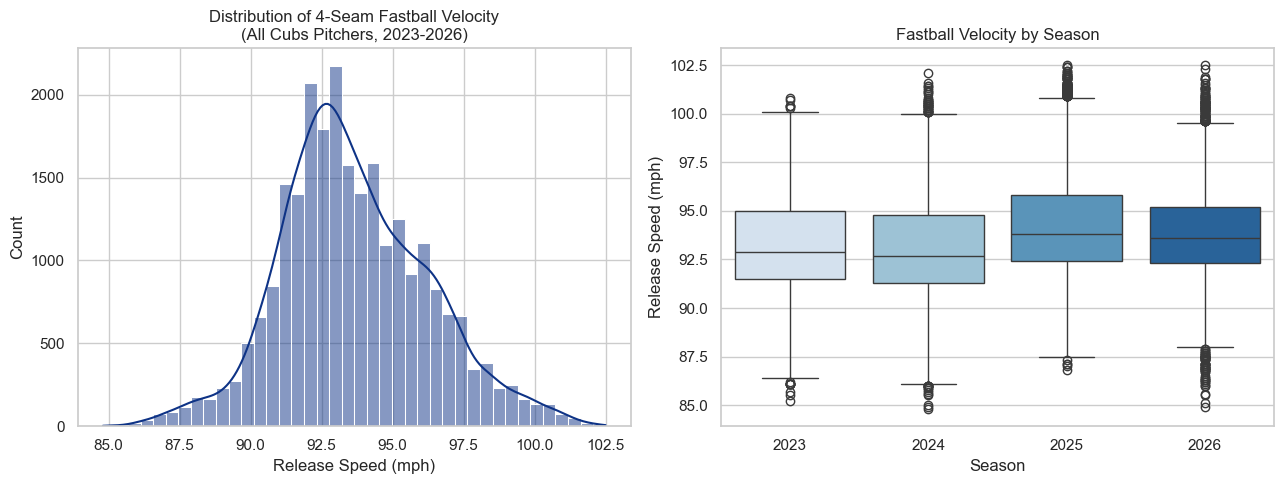

In [8]:
df = load_clean()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["release_speed"], bins=40, color=CUBS_RED, ax=axes[0], kde=True)
axes[0].set_title("Distribution of 4-Seam Fastball Velocity\n(All Cubs Pitchers, 2023-2026)")
axes[0].set_xlabel("Release Speed (mph)")
 
sns.boxplot(data=df, x="season", y="release_speed", ax=axes[1], palette="Blues")
axes[1].set_title("Fastball Velocity by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Release Speed (mph)")
plt.tight_layout()

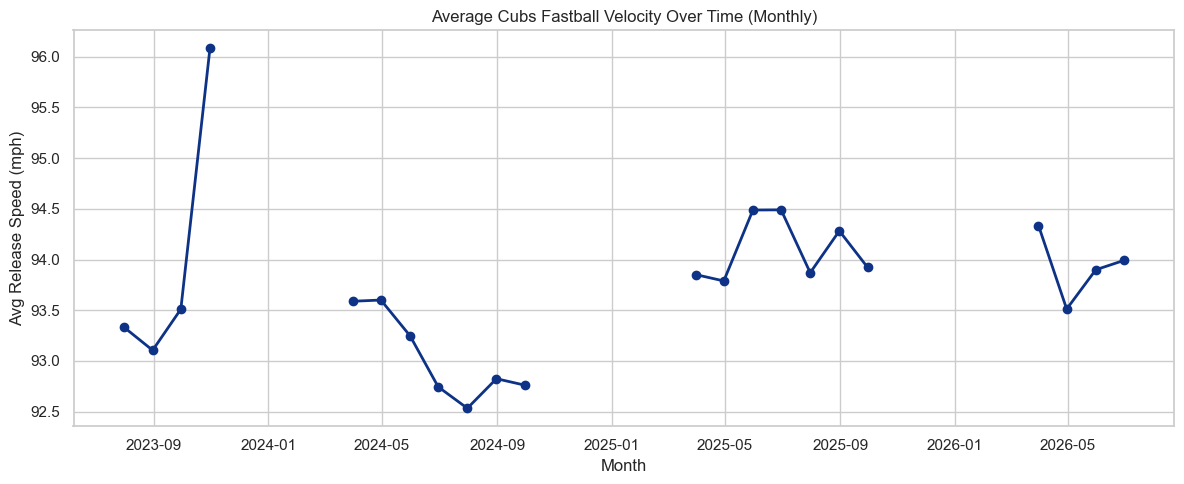

In [9]:
monthly = df.set_index("game_date").resample("ME")["release_speed"].mean()
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, marker="o", color=CUBS_RED, linewidth=2)
plt.title("Average Cubs Fastball Velocity Over Time (Monthly)")
plt.ylabel("Avg Release Speed (mph)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

C:\Users\Lehma\AppData\Local\Temp\ipykernel_4196\3476832395.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_velo.values, y=[str(p) for p in top_velo.index], palette="Blues_r")


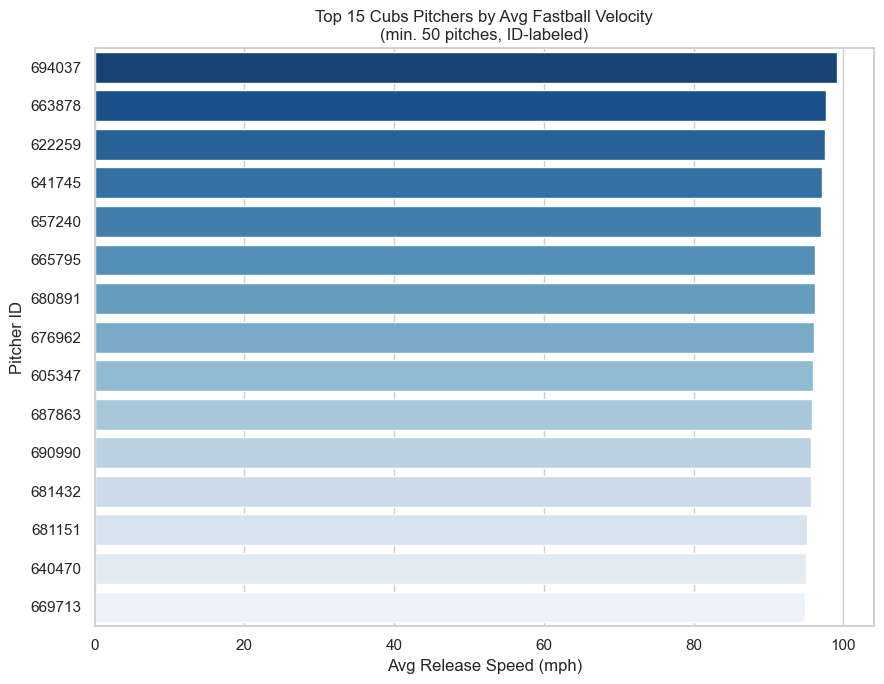

In [10]:
counts = df.groupby("pitcher").size()
qualified = counts[counts >= 50].index
top_velo = (df[df["pitcher"].isin(qualified)]
            .groupby("pitcher")["release_speed"].mean()
            .sort_values(ascending=False).head(15))
plt.figure(figsize=(9, 7))
sns.barplot(x=top_velo.values, y=[str(p) for p in top_velo.index], palette="Blues_r")
plt.title("Top 15 Cubs Pitchers by Avg Fastball Velocity\n(min. 50 pitches, ID-labeled)")
plt.xlabel("Avg Release Speed (mph)")
plt.ylabel("Pitcher ID")
plt.tight_layout()
plt.show()

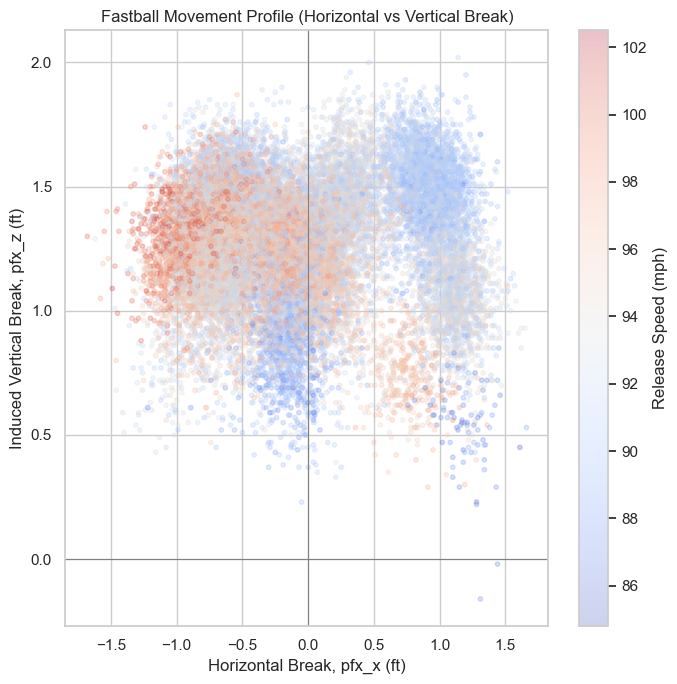

In [11]:
plt.figure(figsize=(7, 7))
sc = plt.scatter(df["pfx_x"], df["pfx_z"], c=df["release_speed"], cmap="coolwarm",
                  alpha=0.25, s=10)
plt.colorbar(sc, label="Release Speed (mph)")
plt.axhline(0, color="grey", lw=0.8)
plt.axvline(0, color="grey", lw=0.8)
plt.title("Fastball Movement Profile (Horizontal vs Vertical Break)")
plt.xlabel("Horizontal Break, pfx_x (ft)")
plt.ylabel("Induced Vertical Break, pfx_z (ft)")
plt.tight_layout()
plt.show()

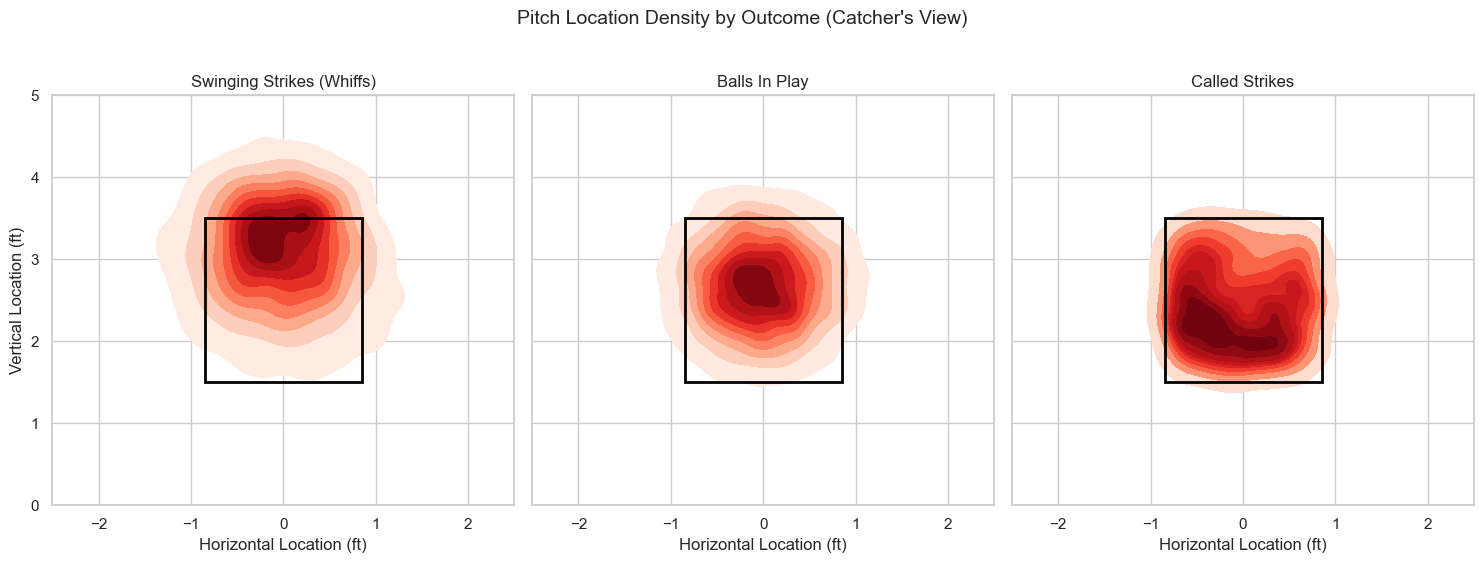

In [12]:
#Strike zone heatmap of pitch locations, split by result
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
zone_box = dict(xmin=-0.85, xmax=0.85, ymin=1.5, ymax=3.5)
for ax, result, title in zip(
        axes,
        ["whiff", "hit_into_play", "called_strike"],
        ["Swinging Strikes (Whiffs)", "Balls In Play", "Called Strikes"]):
    sub = df[df["pitch_result"] == result]
    sns.kdeplot(x=sub["plate_x"], y=sub["plate_z"], fill=True, cmap="Reds",
                thresh=0.05, ax=ax)
    rect = plt.Rectangle((zone_box["xmin"], zone_box["ymin"]),
                          zone_box["xmax"] - zone_box["xmin"],
                          zone_box["ymax"] - zone_box["ymin"],
                          fill=False, edgecolor="black", lw=2)
    ax.add_patch(rect)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 5)
    ax.set_title(title)
    ax.set_xlabel("Horizontal Location (ft)")
axes[0].set_ylabel("Vertical Location (ft)")
plt.suptitle("Pitch Location Density by Outcome (Catcher's View)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

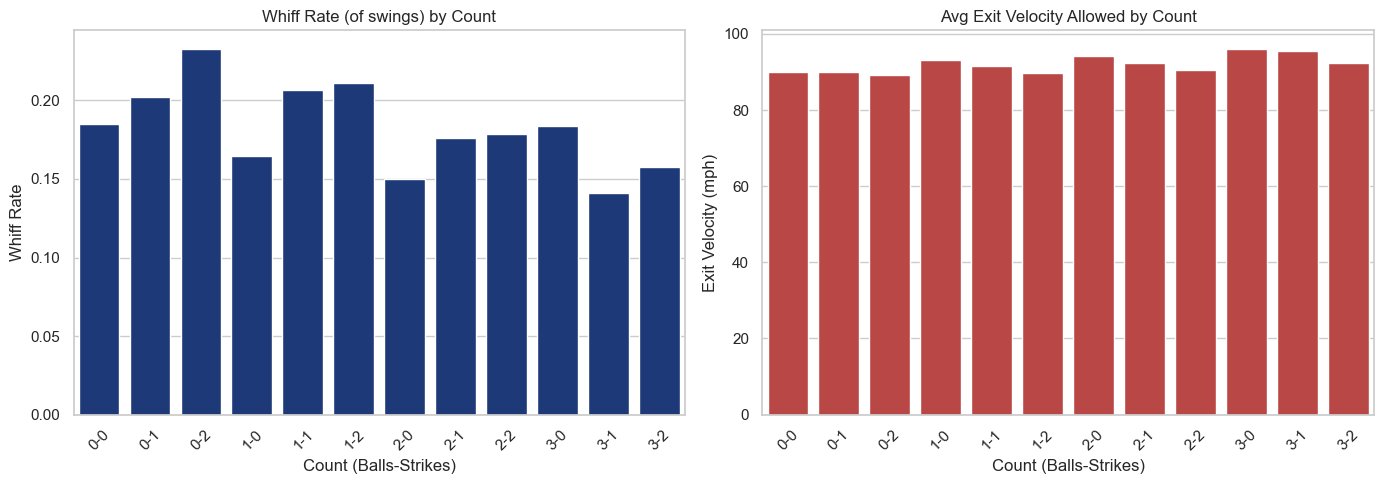

In [13]:
# 6. Whiff rate & exit velocity by count state
count_order = ["0-0","0-1","0-2","1-0","1-1","1-2","2-0","2-1","2-2","3-0","3-1","3-2"]
whiff_by_count = df[df["swung"] == 1].groupby("count_state")["whiff"].mean().reindex(count_order)
ev_by_count = df[df["pitch_result"] == "hit_into_play"].groupby("count_state")["launch_speed"].mean().reindex(count_order)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=whiff_by_count.index, y=whiff_by_count.values, ax=axes[0], color=CUBS_RED)
axes[0].set_title("Whiff Rate (of swings) by Count")
axes[0].set_ylabel("Whiff Rate")
axes[0].set_xlabel("Count (Balls-Strikes)")
axes[0].tick_params(axis="x", rotation=45)
 
sns.barplot(x=ev_by_count.index, y=ev_by_count.values, ax=axes[1], color=CUBS_BLUE)
axes[1].set_title("Avg Exit Velocity Allowed by Count")
axes[1].set_ylabel("Exit Velocity (mph)")
axes[1].set_xlabel("Count (Balls-Strikes)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

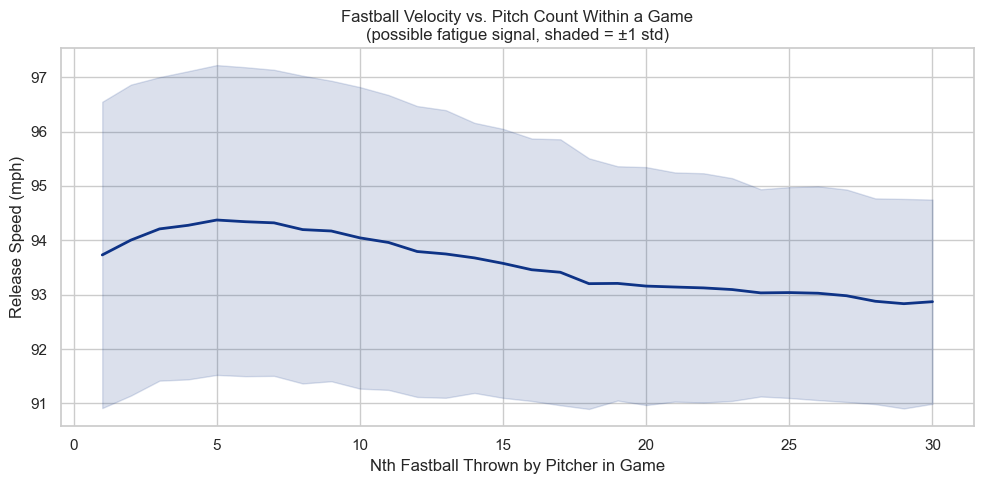

In [14]:
# 7. Velocity decline within a game (fatigue curve)
# ---------------------------------------------------------------
fatigue = df[df["pitcher_pitch_count_in_game"] <= 30].groupby(
    "pitcher_pitch_count_in_game")["release_speed"].agg(["mean", "std", "count"])
fatigue = fatigue[fatigue["count"] >= 20]
plt.figure(figsize=(10, 5))
plt.plot(fatigue.index, fatigue["mean"], color=CUBS_RED, linewidth=2)
plt.fill_between(fatigue.index, fatigue["mean"] - fatigue["std"],
                  fatigue["mean"] + fatigue["std"], color=CUBS_RED, alpha=0.15)
plt.title("Fastball Velocity vs. Pitch Count Within a Game\n(possible fatigue signal, shaded = ±1 std)")
plt.xlabel("Nth Fastball Thrown by Pitcher in Game")
plt.ylabel("Release Speed (mph)")
plt.tight_layout()
plt.show()

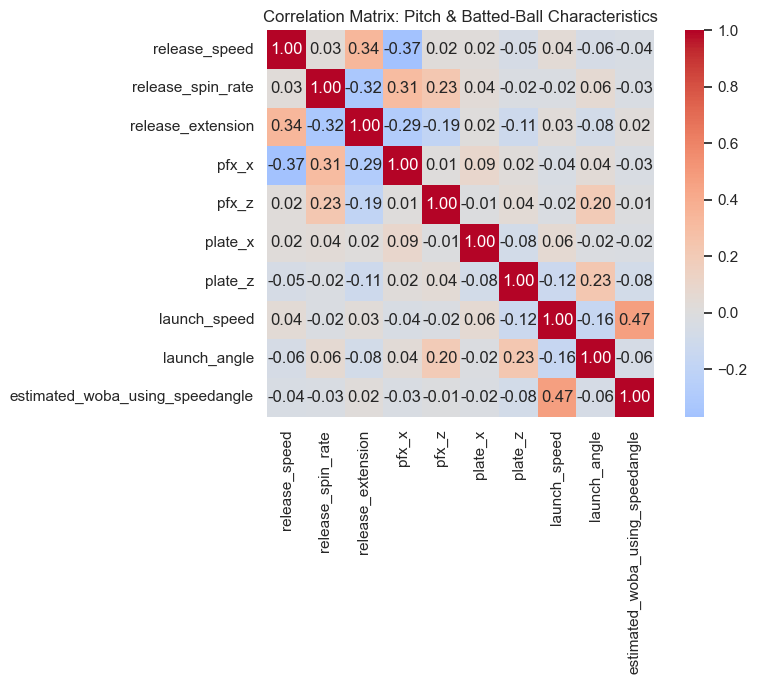

In [15]:
# 8. Correlation heatmap of key numeric features
# ---------------------------------------------------------------
num_cols = ["release_speed", "release_spin_rate", "release_extension", "pfx_x", "pfx_z",
            "plate_x", "plate_z", "launch_speed", "launch_angle", "estimated_woba_using_speedangle"]
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix: Pitch & Batted-Ball Characteristics")
plt.tight_layout()
plt.show()

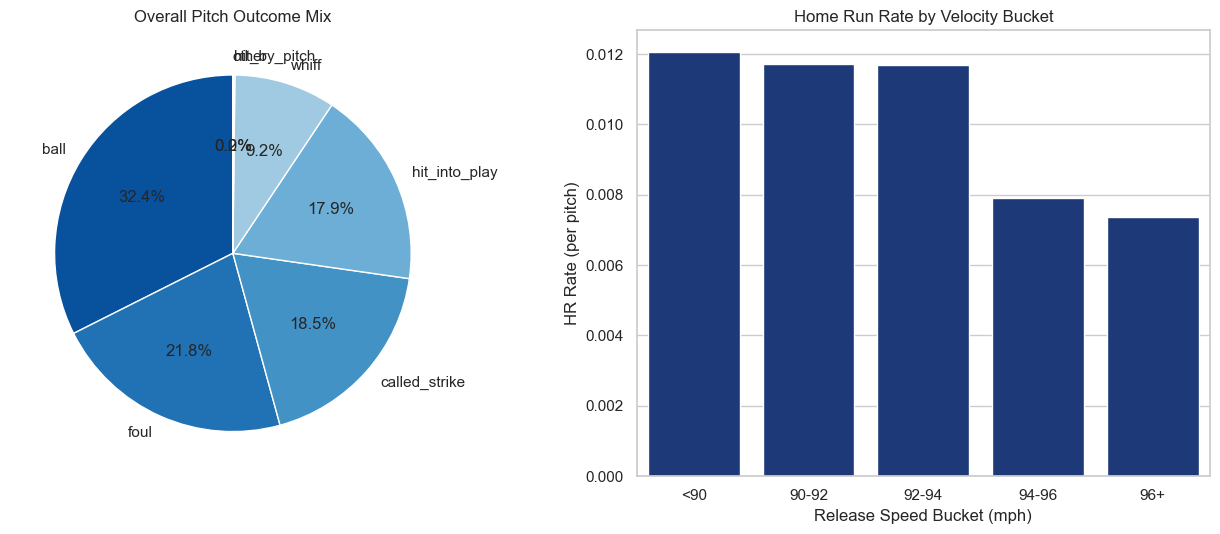

In [16]:

# 9. Outcome mix overall + home run rate by velocity bucket
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
outcome_counts = df["pitch_result"].value_counts()
axes[0].pie(outcome_counts.values, labels=outcome_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Blues_r", len(outcome_counts)), startangle=90)
axes[0].set_title("Overall Pitch Outcome Mix")
 
df["velo_bucket"] = pd.cut(df["release_speed"], bins=[84, 90, 92, 94, 96, 103],
                            labels=["<90", "90-92", "92-94", "94-96", "96+"])
hr_rate = df.groupby("velo_bucket", observed=True)["is_home_run"].mean()
sns.barplot(x=hr_rate.index, y=hr_rate.values, ax=axes[1], color=CUBS_RED)
axes[1].set_title("Home Run Rate by Velocity Bucket")
axes[1].set_xlabel("Release Speed Bucket (mph)")
axes[1].set_ylabel("HR Rate (per pitch)")
plt.tight_layout()
plt.show()

Problem 1
SUB-MODEL 1A (Classification): Ball vs. Called Strike
 
Question: given a pitch the batter did NOT swing at, will it be called a ball or a
strike? This is close to a "physics + rulebook" problem -- it's mostly about where
the pitch crossed the plate relative to the batter's own strike zone

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [61]:
d2 = load_clean()
 
numeric = ["release_speed", "release_pos_x", "release_pos_z", "release_extension",
           "pfx_x", "pfx_z", "plate_x", "plate_z", "release_spin_rate",
           "dist_above_sz_top", "dist_below_sz_bot", "dist_from_zone_center",
           "balls", "strikes", "outs_when_up", "inning", "n_thruorder_pitcher",
           "arm_angle", "same_handed"]
swing_extra = ["bat_speed", "attack_angle", "swing_length", "swing_path_tilt"]
contact_extra = ["intercept_ball_minus_batter_pos_x_inches", "intercept_ball_minus_batter_pos_y_inches"]
swing_all = swing_extra + contact_extra
 
data2 = d2.dropna(subset=numeric + ["pitch_result"]).copy()
data2 = data2[data2["pitch_result"].isin(["ball", "called_strike"])].copy()
data2["matchup"] = data2["matchup"].fillna("UNK")
enc = OrdinalEncoder()
data2["matchup_code"] = enc.fit_transform(data2[["matchup"]])
data2["is_strike"] = (data2["pitch_result"] == "called_strike").astype(int)

In [64]:
feats = numeric + ["matchup_code"]
X, y = data2[feats], data2["is_strike"]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [66]:
cat_idx = [len(numeric)]
clf = HistGradientBoostingClassifier(random_state=42, categorical_features=cat_idx)
clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,[19]
,monotonic_cst,None


In [69]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

In [72]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
baseline = y_test.value_counts(normalize=True).max()
report = classification_report(y_test, y_pred, target_names=["ball", "called_strike"])

In [73]:
print(f"Test accuracy: {acc:.3f}  |  5-fold CV accuracy: {cv_scores.mean():.3f}  |  ROC-AUC: {auc:.3f}")
print(f"Majority-class baseline: {baseline:.3f}\n")
print(report)

Test accuracy: 0.938  |  5-fold CV accuracy: 0.937  |  ROC-AUC: 0.985
Majority-class baseline: 0.637

               precision    recall  f1-score   support

         ball       0.95      0.95      0.95      1612
called_strike       0.91      0.91      0.91       918

     accuracy                           0.94      2530
    macro avg       0.93      0.93      0.93      2530
 weighted avg       0.94      0.94      0.94      2530



In [75]:
# --- Called-strike probability heatmap over the strike zone (classic baseball analytics visual) ---
xs = np.linspace(-2, 2, 60)
zs = np.linspace(1, 4.5, 60)
grid = pd.DataFrame([(x, z) for x in xs for z in zs], columns=["plate_x", "plate_z"])
med = data2[numeric + ["matchup_code"]].median()
for c in feats:
    if c not in ("plate_x", "plate_z"):
        grid[c] = med[c]
# recompute zone-relative features for the grid using median sz_top/sz_bot behavior already baked into dist_* medians
# (dist_above_sz_top/below depend on plate_z, so recompute using typical zone bounds ~1.5-3.5 ft)
grid["dist_above_sz_top"] = grid["plate_z"] - 3.5
grid["dist_below_sz_bot"] = 1.5 - grid["plate_z"]
grid["dist_from_zone_center"] = np.sqrt((grid["plate_x"].abs() / 0.83) ** 2 +
                                         ((grid["plate_z"] - 2.5) / 2.0) ** 2)
grid_proba = clf.predict_proba(grid[feats])[:, 1]
grid["strike_proba"] = grid_proba
pivot = grid.pivot(index="plate_z", columns="plate_x", values="strike_proba")

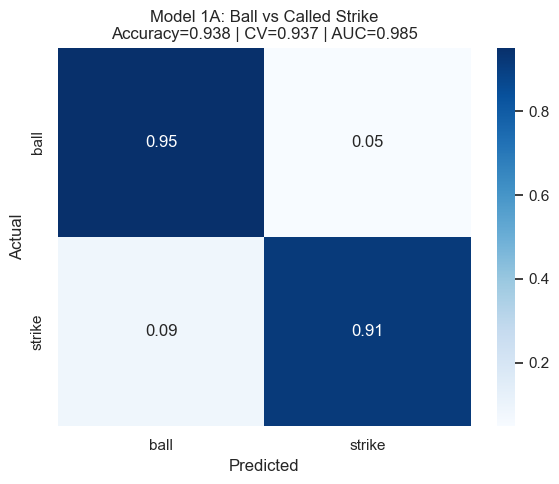

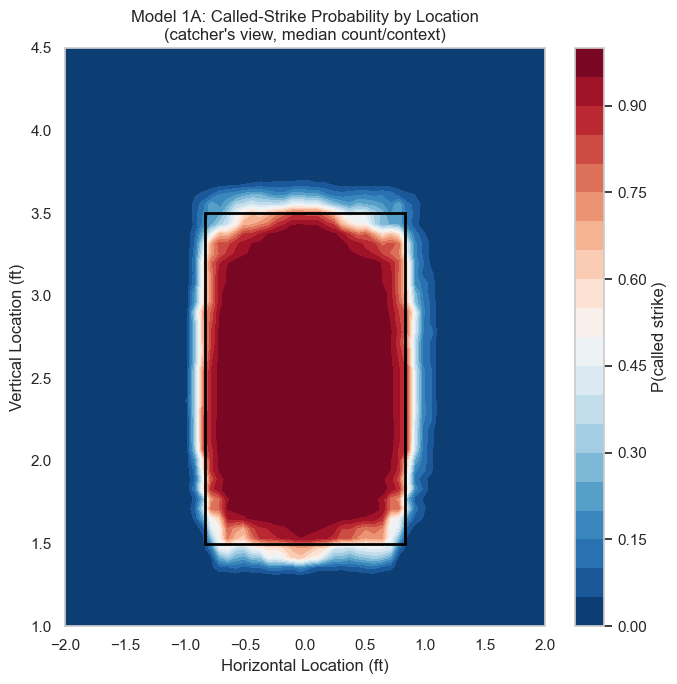

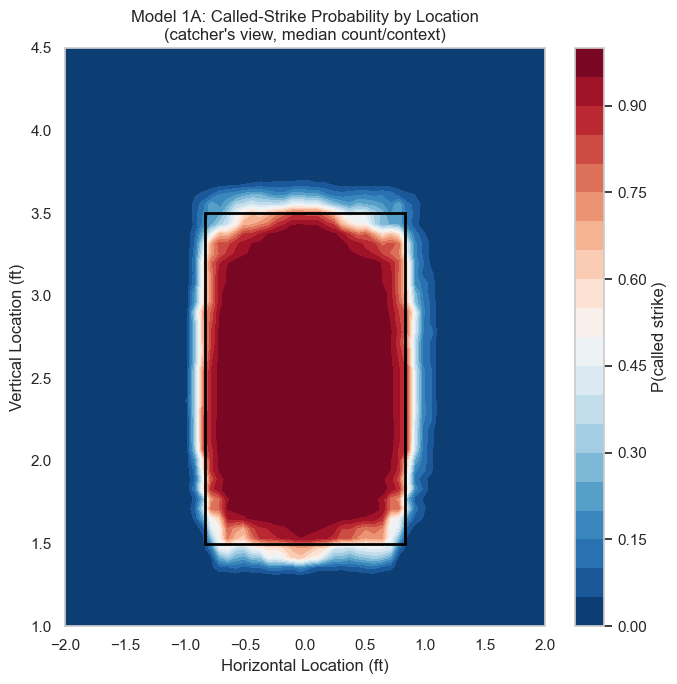

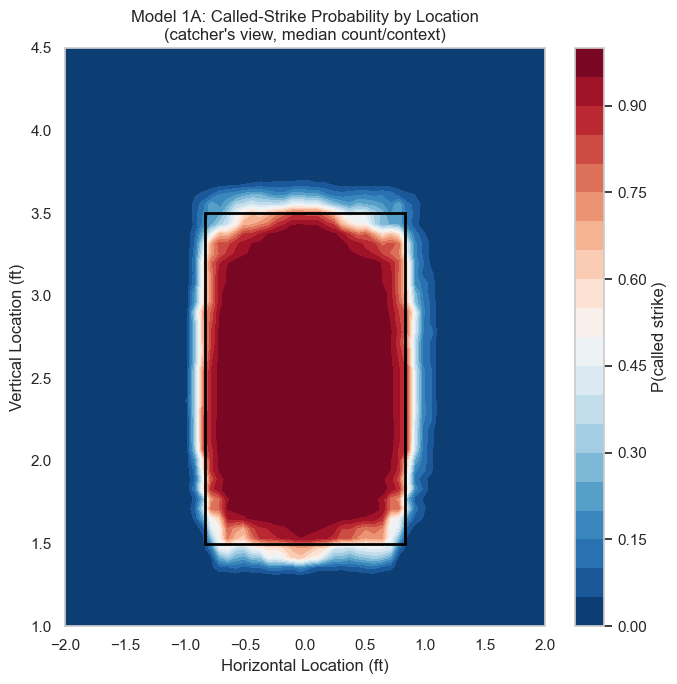

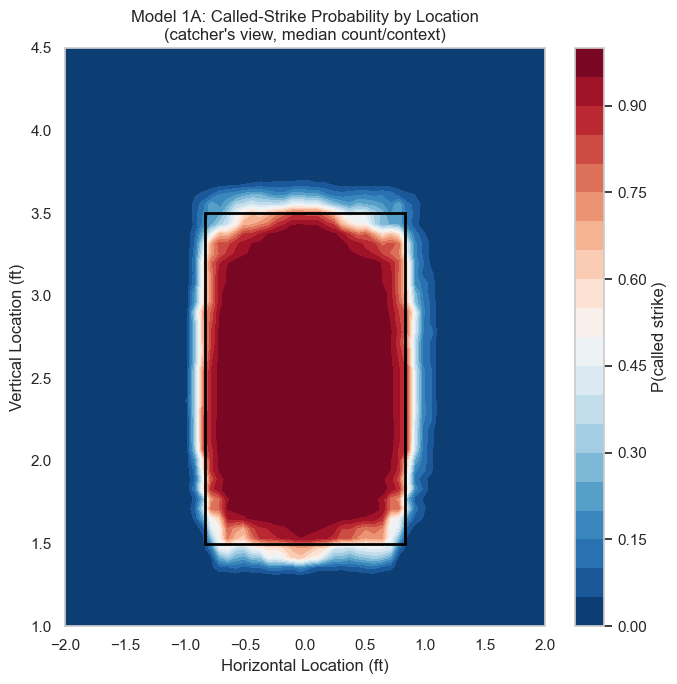

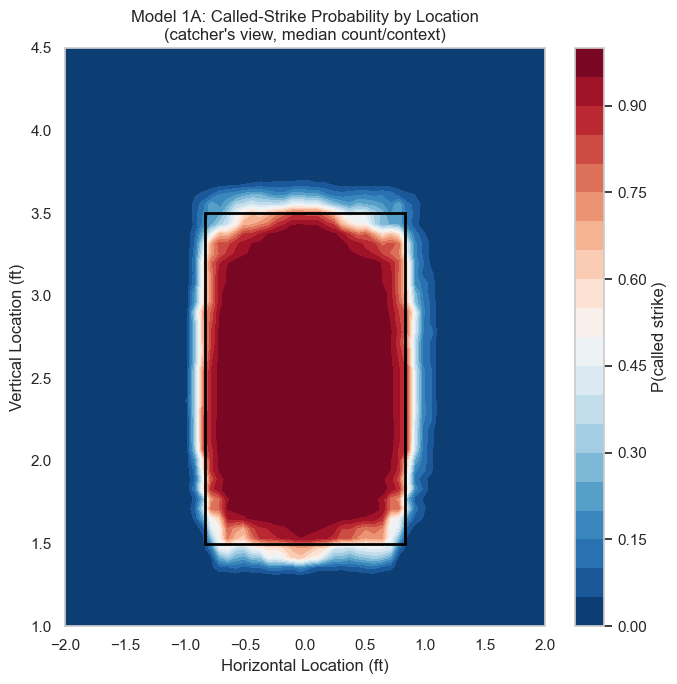

In [82]:
plt.figure(figsize=(7, 7))
plt.contourf(pivot.columns, pivot.index, pivot.values, levels=20, cmap="RdBu_r")
plt.colorbar(label="P(called strike)")
rect = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False, edgecolor="black", lw=2)
plt.gca().add_patch(rect)
plt.title("Model 1A: Called-Strike Probability by Location\n(catcher's view, median count/context)")
plt.xlabel("Horizontal Location (ft)")
plt.ylabel("Vertical Location (ft)")
plt.tight_layout()
plt.show()

Question: Once a batter has decided to swing, what's the outcome -- whiff, foul, or
ball in play? This is the hardest, most irreducible part of the pipeline: it depends
on bat speed, timing down to milliseconds, and swing mechanics that even Statcast's
bat-tracking data only partially captures.

In [83]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

In [86]:
df3 = load_clean()
 
numeric = ["release_speed", "release_pos_x", "release_pos_z", "release_extension",
           "pfx_x", "pfx_z", "plate_x", "plate_z", "release_spin_rate",
           "dist_above_sz_top", "dist_below_sz_bot", "dist_from_zone_center",
           "balls", "strikes", "outs_when_up", "inning", "n_thruorder_pitcher",
           "arm_angle", "same_handed"]
swing_extra = ["bat_speed", "attack_angle", "swing_length", "swing_path_tilt",
               "intercept_ball_minus_batter_pos_x_inches", "intercept_ball_minus_batter_pos_y_inches"]
 
data3 = df3.dropna(subset=numeric + swing_extra + ["pitch_result"]).copy()
data3 = data3[data3["pitch_result"].isin(["foul", "whiff", "hit_into_play"])].copy()
data3["matchup"] = data3["matchup"].fillna("UNK")
enc3 = OrdinalEncoder()
data3["matchup_code"] = enc3.fit_transform(data3[["matchup"]])
 
feats = numeric + swing_extra + ["matchup_code"]
le = LabelEncoder()
y_new = le.fit_transform(data3["pitch_result"])
X_new = data3[feats]
 
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

In [88]:
cat_idx = [len(feats) - 1]
clf = HistGradientBoostingClassifier(random_state=42, categorical_features=cat_idx)
clf.fit(X_train_new, y_train_new)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,[25]
,monotonic_cst,None


In [89]:
y_pred_new = clf.predict(X_test_new)
y_proba_new = clf.predict_proba(X_test_new)
 
acc = accuracy_score(y_test_new, y_pred_new)
baseline = pd.Series(y_test_new).value_counts(normalize=True).max()
ll = log_loss(y_test_new, y_proba_new)
report = classification_report(y_test_new, y_pred_new, target_names=le.classes_)

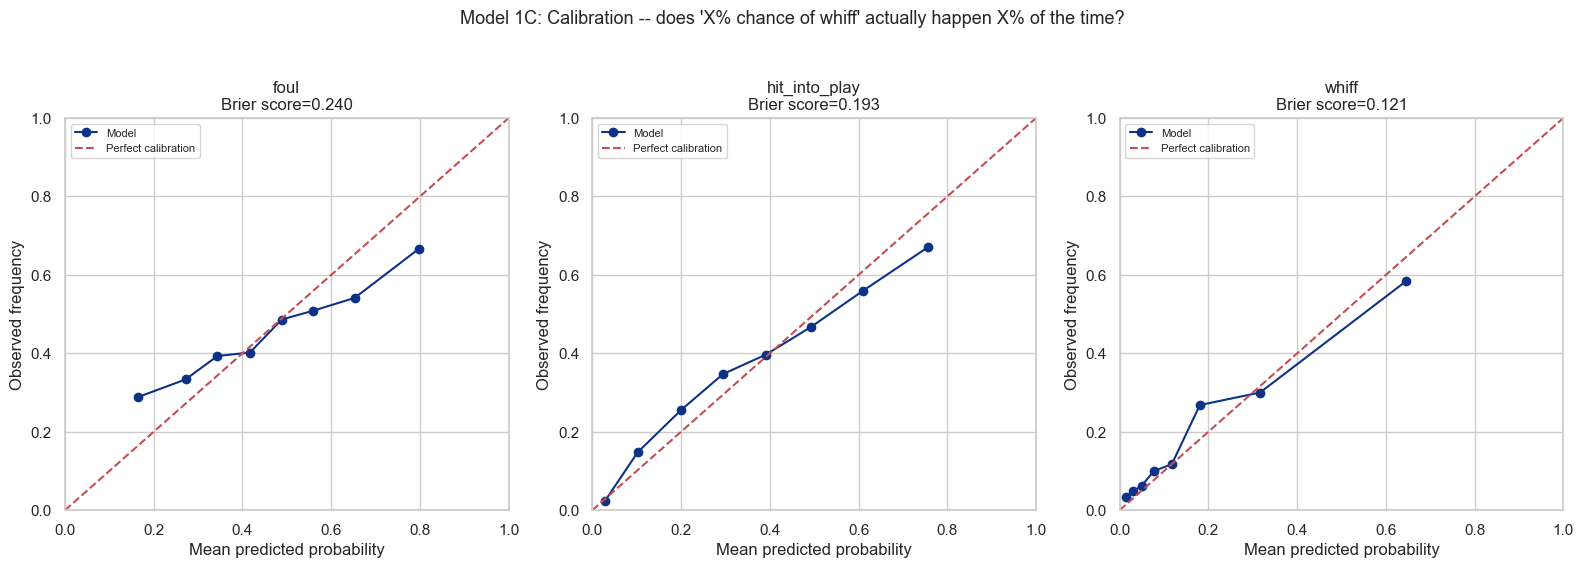

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
brier_scores = {}
for i, cls in enumerate(le.classes_):
    y_true_bin = (y_test_new == i).astype(int)
    prob = y_proba_new[:, i]
    frac_pos, mean_pred = calibration_curve(y_true_bin, prob, n_bins=8, strategy="quantile")
    brier = brier_score_loss(y_true_bin, prob)
    brier_scores[cls] = brier
    axes[i].plot(mean_pred, frac_pos, marker="o", color="#0E3386", label="Model")
    axes[i].plot([0, 1], [0, 1], "r--", label="Perfect calibration")
    axes[i].set_title(f"{cls}\nBrier score={brier:.3f}")
    axes[i].set_xlabel("Mean predicted probability")
    axes[i].set_ylabel("Observed frequency")
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
plt.suptitle("Model 1C: Calibration -- does 'X% chance of whiff' actually happen X% of the time?", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

In [93]:
print("\nBrier scores (lower is better, 0=perfect, 0.25=uninformative for a 50/50 event):")
for cls, b in brier_scores.items():
    print(f"  {cls}: {b:.3f}")


Brier scores (lower is better, 0=perfect, 0.25=uninformative for a 50/50 event):
  foul: 0.240
  hit_into_play: 0.193
  whiff: 0.121


More Swing Decision

In [105]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance

In [107]:
dataf = load_clean()
 
numeric = ["release_speed", "release_pos_x", "release_pos_z", "release_extension",
           "pfx_x", "pfx_z", "plate_x", "plate_z", "release_spin_rate",
           "dist_above_sz_top", "dist_below_sz_bot", "dist_from_zone_center",
           "balls", "strikes", "outs_when_up", "inning", "n_thruorder_pitcher",
           "arm_angle", "same_handed"]
 
datas = dataf.dropna(subset=numeric + ["pitch_result"]).copy()
datas = datas[datas["pitch_result"] != "hit_by_pitch"].copy()  # batter didn't choose to swing or not
datas["matchup"] = datas["matchup"].fillna("UNK")
enc = OrdinalEncoder()
datas["matchup_code"] = enc.fit_transform(datas[["matchup"]])
datas["swung2"] = datas["pitch_result"].isin(["foul", "whiff", "hit_into_play"]).astype(int)

feats = numeric + ["matchup_code"]
X_s, y_s = datas[feats], datas["swung2"]
 
X_trains, X_tests, y_trains, y_tests = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

In [108]:
cats_idx = [len(numeric)]
clfs = HistGradientBoostingClassifier(random_state=42, categorical_features=cats_idx)
clfs.fit(X_trains, y_trains)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,[19]
,monotonic_cst,None


In [109]:
cvs = StratifiedKFold(5, shuffle=True, random_state=42)
cvs_scores = cross_val_score(clfs, X_s, y_s, cv=cvs, scoring="accuracy", n_jobs=-1)

In [110]:
y_pred_val = clfs.predict(X_tests)
y_proba_val = clfs.predict_proba(X_tests)[:, 1]
accs = accuracy_score(y_tests, y_pred_val)
aucs = roc_auc_score(y_tests, y_proba_val)
baseline_val = y_tests.value_counts(normalize=True).max()
reports = classification_report(y_tests, y_pred_val, target_names=["take", "swing"])

In [111]:
print(f"Test accuracy: {accs:.3f}  |  5-fold CV accuracy: {cvs_scores.mean():.3f}  |  ROC-AUC: {aucs:.3f}")

Test accuracy: 0.783  |  5-fold CV accuracy: 0.785  |  ROC-AUC: 0.875


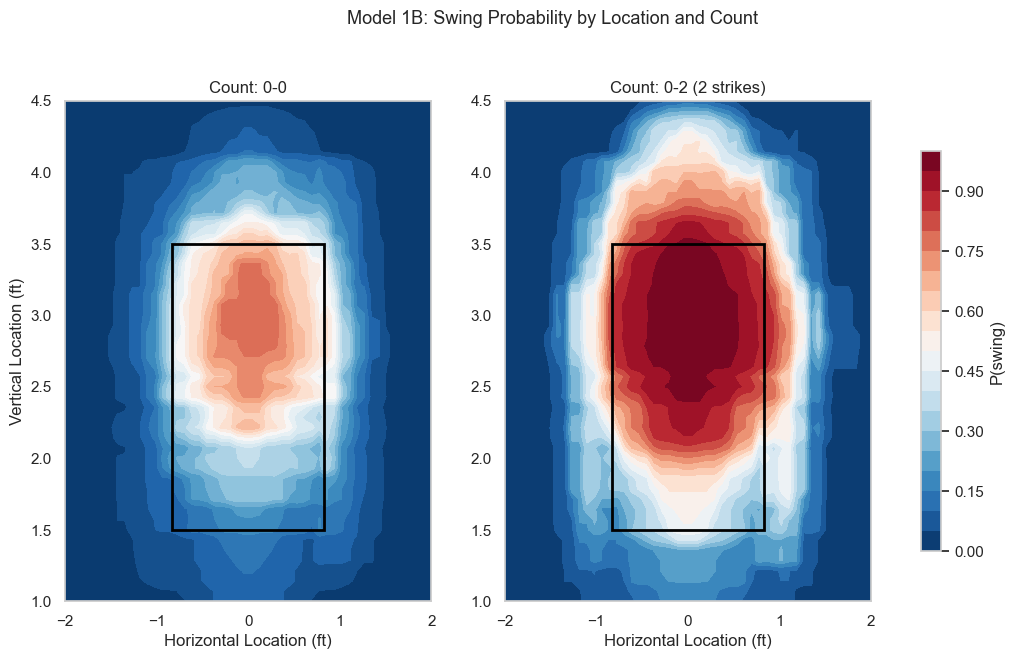

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
xs = np.linspace(-2, 2, 50)
zs = np.linspace(1, 4.5, 50)
med = data[feats].median()
for ax, (b, s), title in zip(axes, [(0, 0), (0, 2)], ["Count: 0-0", "Count: 0-2 (2 strikes)"]):
    grid = pd.DataFrame([(x, z) for x in xs for z in zs], columns=["plate_x", "plate_z"])
    for c in feats:
        if c not in ("plate_x", "plate_z"):
            grid[c] = med[c]
    grid["balls"], grid["strikes"] = b, s
    grid["dist_above_sz_top"] = grid["plate_z"] - 3.5
    grid["dist_below_sz_bot"] = 1.5 - grid["plate_z"]
    grid["dist_from_zone_center"] = np.sqrt((grid["plate_x"].abs() / 0.83) ** 2 +
                                             ((grid["plate_z"] - 2.5) / 2.0) ** 2)
    proba = clfs.predict_proba(grid[feats])[:, 1]
    grid["swing_proba"] = proba
    pivot = grid.pivot(index="plate_z", columns="plate_x", values="swing_proba")
    c = ax.contourf(pivot.columns, pivot.index, pivot.values, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
    rect = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False, edgecolor="black", lw=2)
    ax.add_patch(rect)
    ax.set_title(title)
    ax.set_xlabel("Horizontal Location (ft)")
fig.colorbar(c, ax=axes, label="P(swing)", shrink=0.8)
axes[0].set_ylabel("Vertical Location (ft)")
plt.suptitle("Model 1B: Swing Probability by Location and Count", y=1.02, fontsize=13)
plt.show()

Exit Velocity

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [21]:
dframe = load_clean()
 
base_feats = ["release_speed", "release_pos_x", "release_pos_z", "release_extension",
              "pfx_x", "pfx_z", "plate_x", "plate_z", "release_spin_rate", "balls", "strikes",
              "dist_above_sz_top", "dist_below_sz_bot", "dist_from_zone_center", "same_handed"]
swing_extra = ["bat_speed", "attack_angle", "swing_length", "swing_path_tilt"]
contact_extra = ["intercept_ball_minus_batter_pos_x_inches", "intercept_ball_minus_batter_pos_y_inches"]
 
datafme = dframe[dframe["pitch_result"] == "hit_into_play"].copy()
datafme["matchup"] = datafme["matchup"].fillna("UNK")
enco = OrdinalEncoder()
datafme["matchup_code"] = enco.fit_transform(datafme[["matchup"]])

In [22]:
#Version A: pitch-only ---
featsA = base_feats + ["matchup_code"]
dA = datafme.dropna(subset=featsA + ["launch_speed"]).copy()
Xtr_a, Xte_a, ytr_a, yte_a = train_test_split(dA[featsA], dA["launch_speed"], test_size=0.2, random_state=42)
modelA = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1)
modelA.fit(Xtr_a, ytr_a)
predA = modelA.predict(Xte_a)
r2_a, mae_a = r2_score(yte_a, predA), mean_absolute_error(yte_a, predA)

In [23]:
#Version B: pitch + swing (bat-tracking) ---
featsB = base_feats + swing_extra + ["matchup_code"]
dB = datafme.dropna(subset=featsB + ["launch_speed"]).copy()
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(dB[featsB], dB["launch_speed"], test_size=0.2, random_state=42)
cat_idx = [len(base_feats) + len(swing_extra)]
modelB = HistGradientBoostingRegressor(random_state=42, categorical_features=cat_idx,
                                        max_iter=250, max_depth=None, learning_rate=0.06,
                                        min_samples_leaf=20)
modelB.fit(Xtr_b, ytr_b)
predB = modelB.predict(Xte_b)
r2_b, mae_b = r2_score(yte_b, predB), mean_absolute_error(yte_b, predB)

In [24]:
#Version C: pitch + swing + contact point -- 3-way algorithm comparison ---
featsC = base_feats + swing_extra + contact_extra + ["matchup_code"]
dC = datafme.dropna(subset=featsC + ["launch_speed"]).copy()
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(dC[featsC], dC["launch_speed"], test_size=0.2, random_state=42)
cat_idx_c = [len(base_feats) + len(swing_extra) + len(contact_extra)]

In [25]:
model_histgb = HistGradientBoostingRegressor(random_state=42, categorical_features=cat_idx_c,
                                              max_iter=150, max_depth=None, learning_rate=0.02,
                                              min_samples_leaf=10, l2_regularization=0.0)
model_histgb.fit(Xtr_c, ytr_c)
pred_histgb = model_histgb.predict(Xte_c)

In [26]:
model_xgb = XGBRegressor(random_state=42, n_estimators=150, max_depth=6, learning_rate=0.05,
                          subsample=0.85, colsample_bytree=0.85, reg_lambda=2.0)
model_xgb.fit(Xtr_c, ytr_c)
pred_xgb = model_xgb.predict(Xte_c)

In [27]:
model_lgbm = LGBMRegressor(random_state=42, verbosity=-1, n_estimators=250, max_depth=4,
                            learning_rate=0.05, subsample=1.0, colsample_bytree=0.85,
                            reg_lambda=0.5, num_leaves=63)
model_lgbm.fit(Xtr_c, ytr_c)
pred_lgbm = model_lgbm.predict(Xte_c)

In [29]:
algo_results = {}
for name, pred in [("HistGB", pred_histgb), ("XGBoost", pred_xgb), ("LightGBM", pred_lgbm)]:
    algo_results[name] = (r2_score(yte_c, pred), mean_absolute_error(yte_c, pred))

In [30]:
print("\nVersion C algorithm comparison (pitch+swing+contact features, all tuned):")
for name, (r2v, maev) in sorted(algo_results.items(), key=lambda kv: -kv[1][0]):
    print(f"  {name:<10} R2={r2v:.3f}  MAE={maev:.2f} mph")


Version C algorithm comparison (pitch+swing+contact features, all tuned):
  LightGBM   R2=0.432  MAE=7.88 mph
  XGBoost    R2=0.431  MAE=7.84 mph
  HistGB     R2=0.422  MAE=7.98 mph


In [31]:
best_algo = max(algo_results, key=lambda k: algo_results[k][0])
best_model = {"HistGB": model_histgb, "XGBoost": model_xgb, "LightGBM": model_lgbm}[best_algo]
predC = {"HistGB": pred_histgb, "XGBoost": pred_xgb, "LightGBM": pred_lgbm}[best_algo]
r2_c, mae_c = algo_results[best_algo]
print(f"\nBest: {best_algo} (R2={r2_c:.3f}, MAE={mae_c:.2f} mph) -- used as final Version C model")


Best: LightGBM (R2=0.432, MAE=7.88 mph) -- used as final Version C model


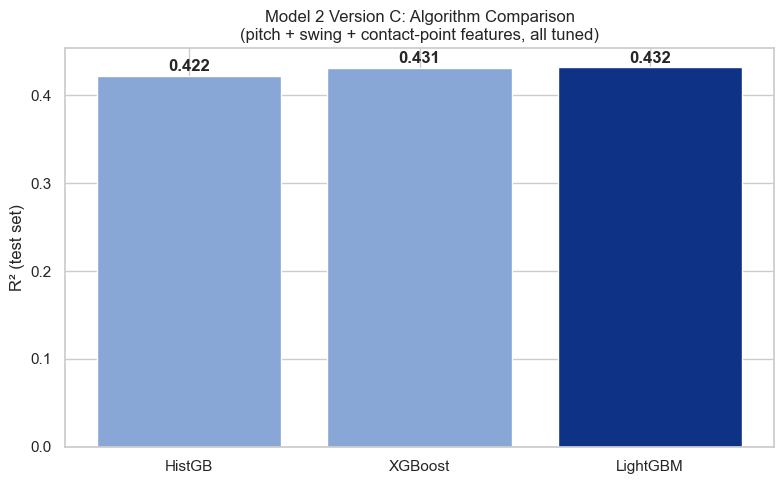

In [32]:
# --- Algorithm comparison chart ---
plt.figure(figsize=(8, 5))
names = list(algo_results.keys())
r2_vals = [algo_results[n][0] for n in names]
colors_algo = ["#0E3386" if n == best_algo else "#88a6d6" for n in names]
plt.bar(names, r2_vals, color=colors_algo)
plt.title("Model 2 Version C: Algorithm Comparison\n(pitch + swing + contact-point features, all tuned)")
plt.ylabel("R² (test set)")
for i, v in enumerate(r2_vals):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

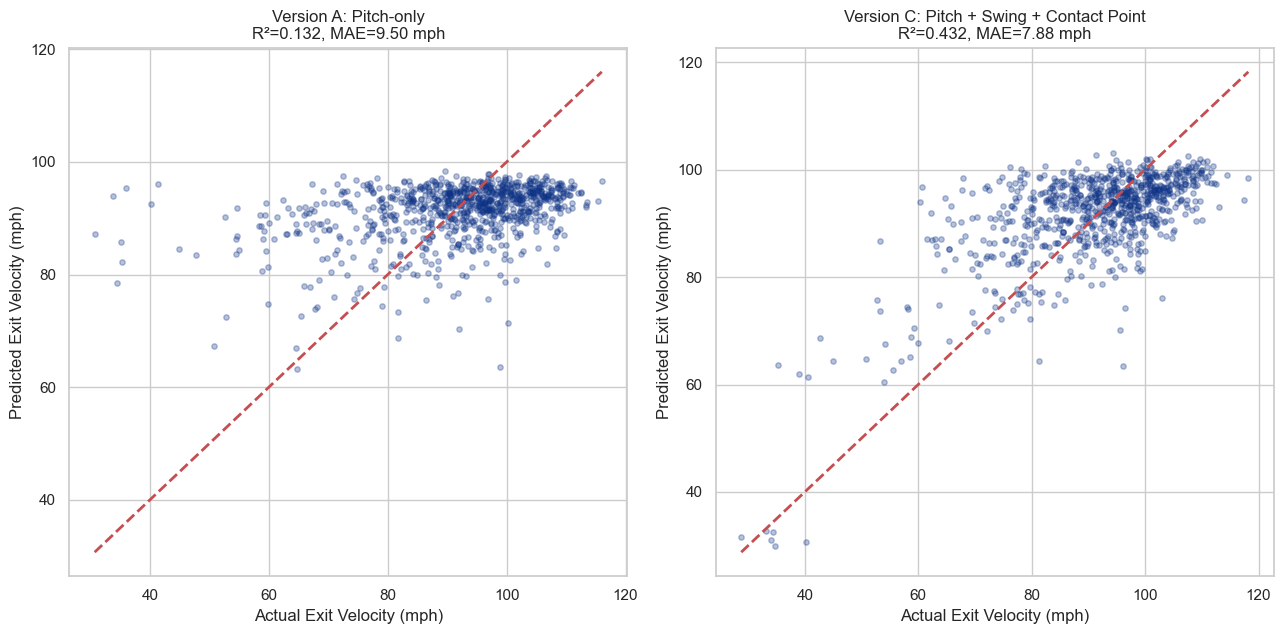

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, yte, pred, r2, mae, title in [
        (axes[0], yte_a, predA, r2_a, mae_a, "Version A: Pitch-only"),
        (axes[1], yte_c, predC, r2_c, mae_c, "Version C: Pitch + Swing + Contact Point")]:
    ax.scatter(yte, pred, alpha=0.3, s=15, color="#0E3386")
    lims = [yte.min(), yte.max()]
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Actual Exit Velocity (mph)")
    ax.set_ylabel("Predicted Exit Velocity (mph)")
    ax.set_title(f"{title}\nR²={r2:.3f}, MAE={mae:.2f} mph")
plt.tight_layout()
plt.show()

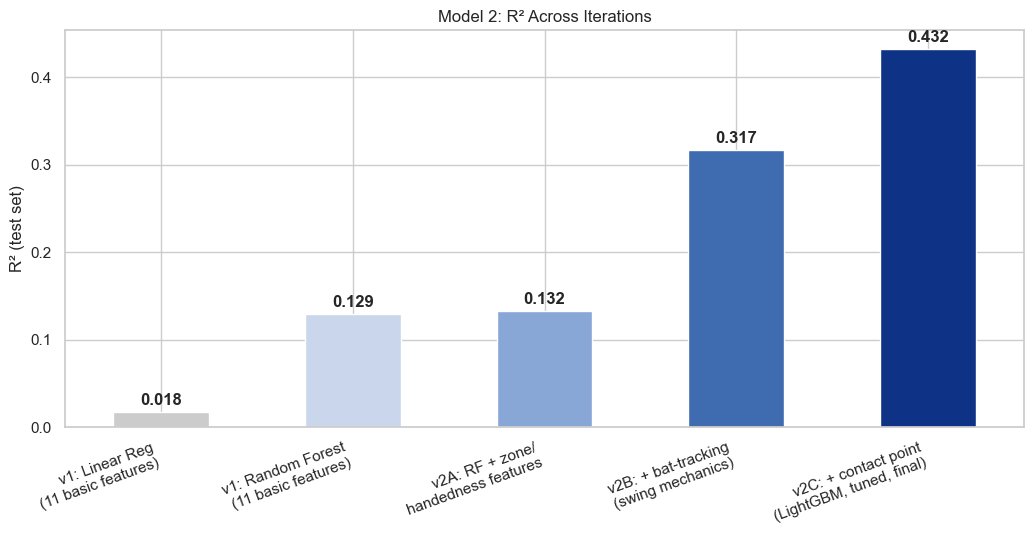

In [34]:
# --- R2 comparison across iterations ---
comparison = pd.Series({
    "v1: Linear Reg\n(11 basic features)": 0.018,
    "v1: Random Forest\n(11 basic features)": 0.129,
    "v2A: RF + zone/\nhandedness features": r2_a,
    "v2B: + bat-tracking\n(swing mechanics)": r2_b,
    f"v2C: + contact point\n({best_algo}, tuned, final)": r2_c,
})
plt.figure(figsize=(10.5, 5.5))
colors = ["#cccccc", "#c9d6ec", "#88a6d6", "#3f6bb0", "#0E3386"]
comparison.plot(kind="bar", color=colors)
plt.title("Model 2: R² Across Iterations")
plt.ylabel("R² (test set)")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(comparison.values):
    plt.text(i, v + 0.008, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

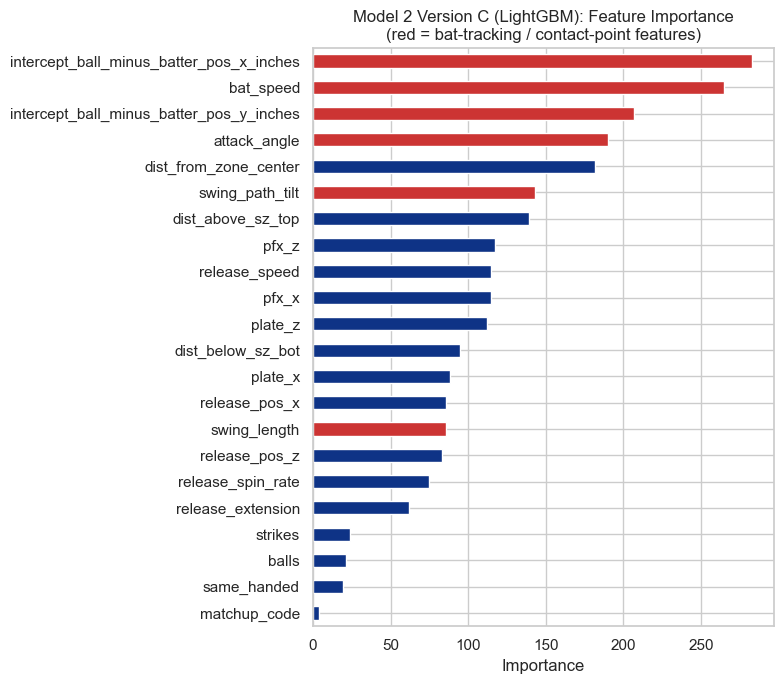

In [35]:
# --- Feature importance, best algorithm from Version C ---
perm_feats = featsC
importances = pd.Series(best_model.feature_importances_ if hasattr(best_model, "feature_importances_") else
                         np.zeros(len(perm_feats)), index=perm_feats)
if importances.sum() == 0:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(best_model, Xte_c, yte_c, n_repeats=8, random_state=42, n_jobs=-1)
    importances = pd.Series(perm.importances_mean, index=perm_feats)
importances = importances.sort_values(ascending=True)
plt.figure(figsize=(8, 7))
colors2 = ["#CC3433" if f in (swing_extra + contact_extra) else "#0E3386" for f in importances.index]
importances.plot(kind="barh", color=colors2)
plt.title(f"Model 2 Version C ({best_algo}): Feature Importance\n(red = bat-tracking / contact-point features)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

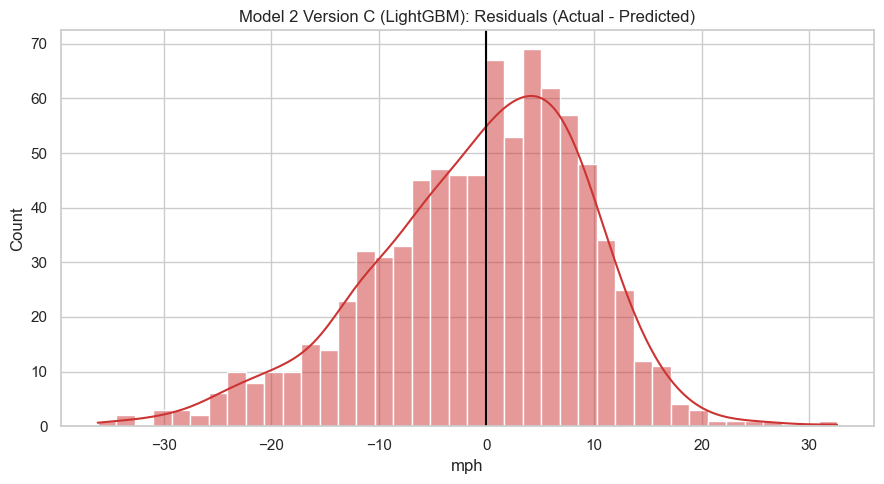

In [36]:
# --- Residuals, best algorithm ---
residuals = yte_c - predC
plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=40, color="#CC3433", kde=True)
plt.axvline(0, color="black", lw=1.5)
plt.title(f"Model 2 Version C ({best_algo}): Residuals (Actual - Predicted)")
plt.xlabel("mph")
plt.tight_layout()
plt.show()

Pitchers Clustering

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [94]:
dframe = load_clean()
 
profile_features = [
    "release_speed", "release_spin_rate", "pfx_x", "pfx_z",
    "release_pos_x", "release_pos_z", "release_extension",
]
 
counts = dframe.groupby("pitcher").size()
qualified = counts[counts >= 30].index  # need enough pitches for a stable average
pitcher_profiles = (dframe[dframe["pitcher"].isin(qualified)]
                     .groupby("pitcher")[profile_features].mean())
pitcher_profiles["n_pitches"] = counts[qualified]
 
print(f"Pitchers used for clustering: {len(pitcher_profiles)}")

Pitchers used for clustering: 52


In [97]:
X_vals = pitcher_profiles[profile_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vals)

In [98]:
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)
best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores by k:", sil_scores)
print("Chosen k:", best_k)

C:\Users\Lehma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lehma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lehma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lehma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Silhouette scores by k: {2: 0.289004342189932, 3: 0.201177896728587, 4: 0.20202292488956392, 5: 0.20288837123523124, 6: 0.21652953999478114, 7: 0.21876711030644305}
Chosen k: 2


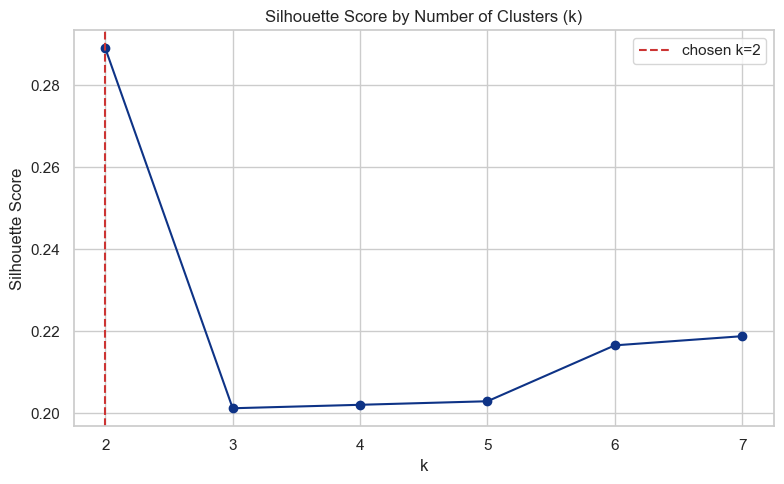

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color="#0E3386")
plt.axvline(best_k, color="#CC3433", linestyle="--", label=f"chosen k={best_k}")
plt.title("Silhouette Score by Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
X_vals["cluster"] = km.fit_predict(X_scaled)

C:\Users\Lehma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [101]:
# --- PCA for 2D visualization ---
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
X_vals["pc1"], X_vals["pc2"] = coords[:, 0], coords[:, 1]


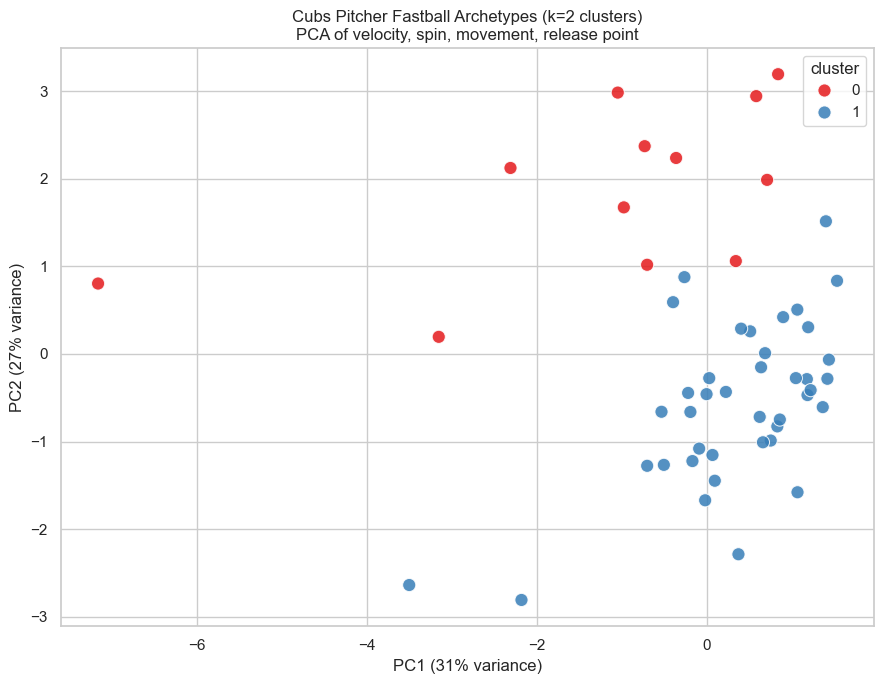

In [103]:
plt.figure(figsize=(9, 7))
sns.scatterplot(data=X_vals, x="pc1", y="pc2", hue="cluster", palette="Set1", s=90, alpha=0.85)
plt.title(f"Cubs Pitcher Fastball Archetypes (k={best_k} clusters)\nPCA of velocity, spin, movement, release point")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% variance)")
plt.tight_layout()
plt.show()

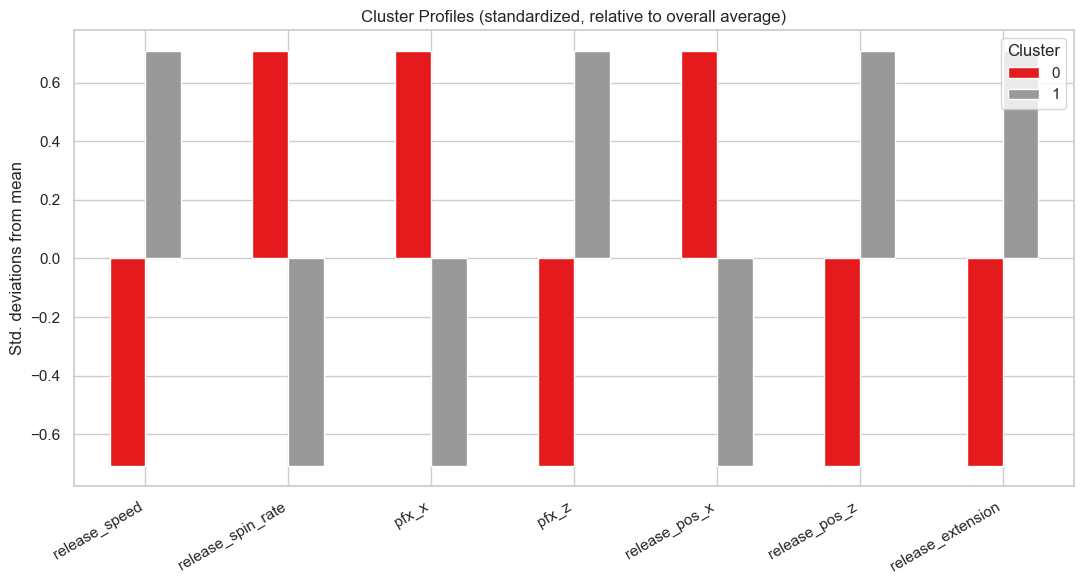

In [104]:
# --- Cluster profile summary (radar-ish bar comparison) ---
cluster_means = X_vals.groupby("cluster")[profile_features].mean()
cluster_means_norm = (cluster_means - cluster_means.mean()) / cluster_means.std()
 
plt.figure(figsize=(11, 6))
cluster_means_norm.T.plot(kind="bar", ax=plt.gca(), colormap="Set1")
plt.title("Cluster Profiles (standardized, relative to overall average)")
plt.ylabel("Std. deviations from mean")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Time Series Modeling 
Team-level fastball velocity trend + forecasting
 
Question: how does the Cubs' team-average fastball velocity trend over the season and
across seasons, and can we forecast it a few weeks ahead?

In [6]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet

In [7]:
time_data = load_clean()
#Weekly team-average velocity series (only weeks with actual games)
weekly = time_data.set_index("game_date").resample("W").agg(
    release_speed=("release_speed", "mean"), n_pitches=("release_speed", "size"))
weekly = weekly[weekly["n_pitches"] > 0].reset_index()
weekly.columns = ["ds", "y", "n_pitches"]

In [8]:
print(f"Weekly series: {len(weekly)} weeks with data, "
      f"{weekly['ds'].min().date()} to {weekly['ds'].max().date()}, std={weekly['y'].std():.3f} mph")

Weekly series: 80 weeks with data, 2023-07-30 to 2026-07-05, std=0.713 mph


In [9]:
holdout_n = 8
train = weekly.iloc[:-holdout_n].copy()
test = weekly.iloc[-holdout_n:].copy()
 
results = {}
preds = {}
 
# Prophet variants
for yearly, cps, label in [
        (True, 0.1, "Prophet (yearly seasonality, default flexibility)"),
        (False, 0.1, "Prophet (trend only, default flexibility)"),
        (False, 0.01, "Prophet (trend only, low flexibility) -- FINAL CHOICE"),
]:
    m = Prophet(yearly_seasonality=yearly, weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=cps)
    m.fit(train[["ds", "y"]])
    fut = m.make_future_dataframe(periods=holdout_n, freq="W")
    fc = m.predict(fut)
    pred = fc.set_index("ds").loc[test["ds"], "yhat"].values
    preds[label] = pred
    results[label] = mean_absolute_error(test["y"], pred)

15:19:08 - cmdstanpy - INFO - Chain [1] start processing
15:19:09 - cmdstanpy - INFO - Chain [1] done processing
15:19:09 - cmdstanpy - INFO - Chain [1] start processing
15:19:09 - cmdstanpy - INFO - Chain [1] done processing
15:19:09 - cmdstanpy - INFO - Chain [1] start processing
15:19:10 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
# Statsmodels baselines
ses = SimpleExpSmoothing(train["y"].values).fit()
preds["Simple exponential smoothing"] = ses.forecast(holdout_n)
results["Simple exponential smoothing"] = mean_absolute_error(test["y"], preds["Simple exponential smoothing"])

In [11]:
holt = Holt(train["y"].values).fit()
preds["Holt linear trend"] = holt.forecast(holdout_n)
results["Holt linear trend"] = mean_absolute_error(test["y"], preds["Holt linear trend"])

In [12]:
for n in [4, 8, 12]:
    pred_flat = np.full(holdout_n, train["y"].tail(n).mean())
    label = f"Rolling mean, last {n} weeks"
    preds[label] = pred_flat
    results[label] = mean_absolute_error(test["y"], pred_flat)

In [13]:
results_sorted = dict(sorted(results.items(), key=lambda kv: kv[1]))
print("\nBacktest MAE, best to worst:")
for name, mae in results_sorted.items():
    print(f"  {name:<52} MAE={mae:.3f} mph")


Backtest MAE, best to worst:
  Rolling mean, last 12 weeks                          MAE=0.395 mph
  Prophet (trend only, low flexibility) -- FINAL CHOICE MAE=0.412 mph
  Rolling mean, last 8 weeks                           MAE=0.429 mph
  Simple exponential smoothing                         MAE=0.507 mph
  Prophet (trend only, default flexibility)            MAE=0.508 mph
  Rolling mean, last 4 weeks                           MAE=0.623 mph
  Holt linear trend                                    MAE=0.803 mph
  Prophet (yearly seasonality, default flexibility)    MAE=0.921 mph


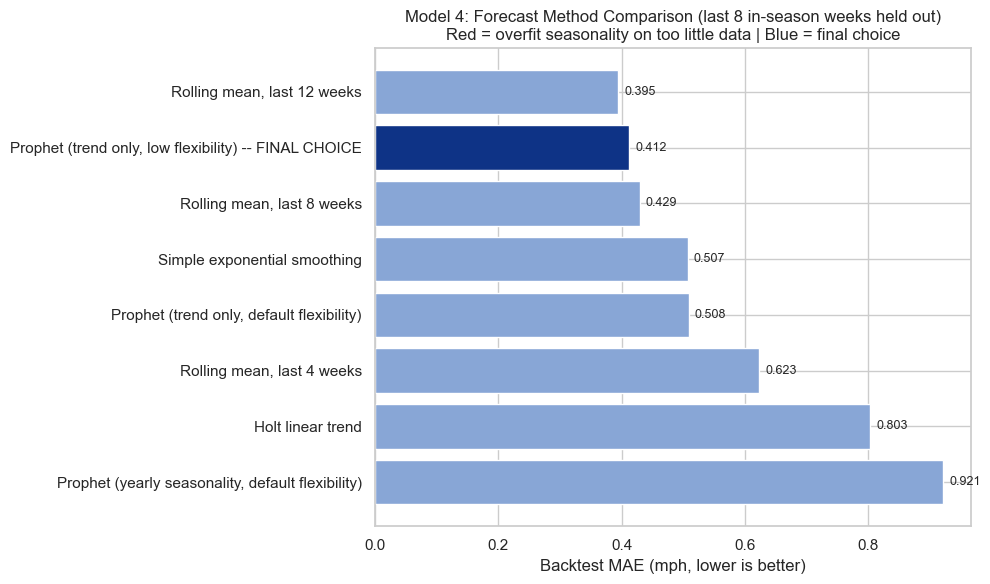

In [14]:
# --- Backtest comparison chart ---
plt.figure(figsize=(10, 6))
names = list(results_sorted.keys())
vals = list(results_sorted.values())
colors = ["#0E3386" if "FINAL CHOICE" in n else ("#CC3433" if "default flexibility) " in n and "yearly" in n else "#88a6d6") for n in names]
plt.barh(names, vals, color=colors)
plt.xlabel("Backtest MAE (mph, lower is better)")
plt.title("Model 4: Forecast Method Comparison (last 8 in-season weeks held out)\n"
          "Red = overfit seasonality on too little data | Blue = final choice")
plt.gca().invert_yaxis()
for i, v in enumerate(vals):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

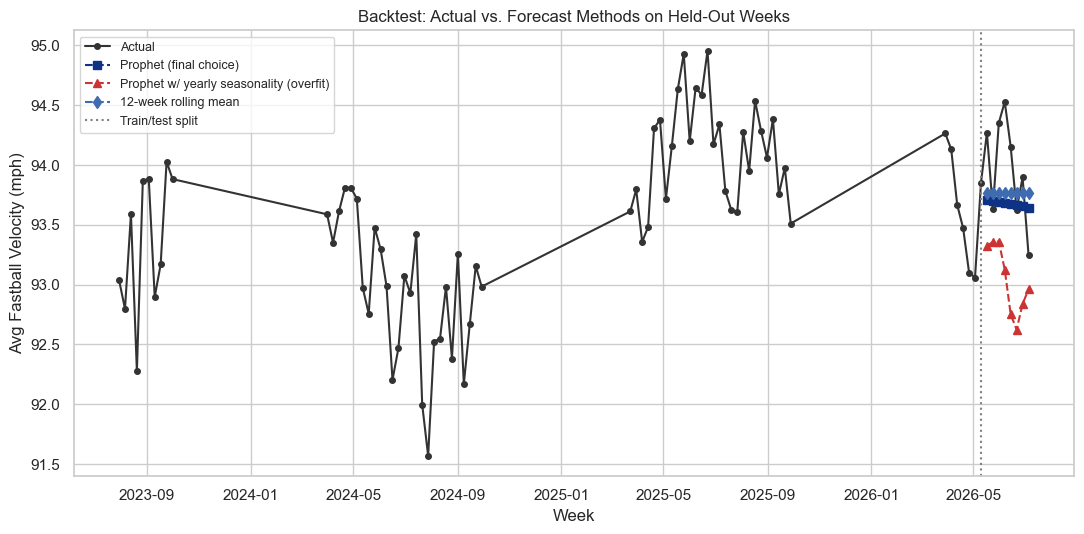

In [15]:
plt.figure(figsize=(11, 5.5))
plt.plot(weekly["ds"], weekly["y"], "o-", color="#333333", label="Actual", markersize=4)
plt.plot(test["ds"], preds["Prophet (trend only, low flexibility) -- FINAL CHOICE"], "s--",
          color="#0E3386", label="Prophet (final choice)")
plt.plot(test["ds"], preds["Prophet (yearly seasonality, default flexibility)"], "^--",
          color="#CC3433", label="Prophet w/ yearly seasonality (overfit)")
plt.plot(test["ds"], preds["Rolling mean, last 12 weeks"], "d--",
          color="#3f6bb0", label="12-week rolling mean")
plt.axvline(train["ds"].iloc[-1], color="grey", linestyle=":", label="Train/test split")
plt.title("Backtest: Actual vs. Forecast Methods on Held-Out Weeks")
plt.ylabel("Avg Fastball Velocity (mph)")
plt.xlabel("Week")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
# Final model: fit on ALL data with the honestly-best config, forecast 6 weeks ahead
m_final = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
                   changepoint_prior_scale=0.01)
m_final.fit(weekly[["ds", "y"]])
future = m_final.make_future_dataframe(periods=6, freq="W")
forecast = m_final.predict(future)
 
rolling_12wk_forecast = weekly["y"].tail(12).mean()


15:22:51 - cmdstanpy - INFO - Chain [1] start processing
15:22:51 - cmdstanpy - INFO - Chain [1] done processing


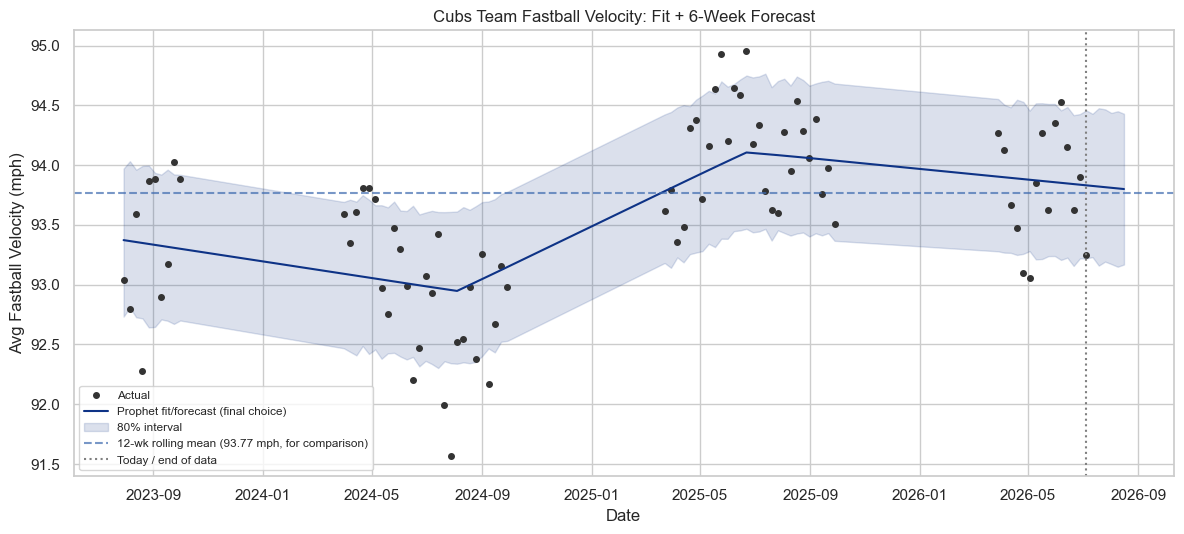

In [17]:
plt.figure(figsize=(12, 5.5))
plt.plot(weekly["ds"], weekly["y"], "o", color="#333333", label="Actual", markersize=4)
plt.plot(forecast["ds"], forecast["yhat"], "-", color="#0E3386", label="Prophet fit/forecast (final choice)")
plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                  color="#0E3386", alpha=0.15, label="80% interval")
last_actual_date = weekly["ds"].max()
plt.axhline(rolling_12wk_forecast, color="#3f6bb0", linestyle="--", alpha=0.7,
            label=f"12-wk rolling mean ({rolling_12wk_forecast:.2f} mph, for comparison)")
plt.axvline(last_actual_date, color="grey", linestyle=":", label="Today / end of data")
plt.title("Cubs Team Fastball Velocity: Fit + 6-Week Forecast")
plt.ylabel("Avg Fastball Velocity (mph)")
plt.xlabel("Date")
plt.legend(fontsize=8.5, loc="lower left")
plt.tight_layout()
plt.show()

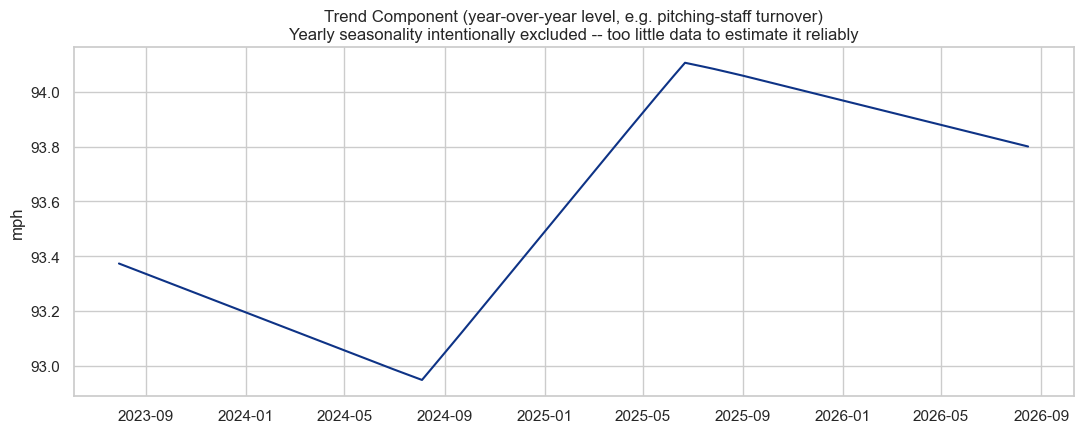

In [18]:
# --- Trend component only (seasonality omitted from final model, so nothing to decompose there) ---
plt.figure(figsize=(11, 4.5))
plt.plot(forecast["ds"], forecast["trend"], color="#0E3386")
plt.title("Trend Component (year-over-year level, e.g. pitching-staff turnover)\n"
          "Yearly seasonality intentionally excluded -- too little data to estimate it reliably")
plt.ylabel("mph")
plt.tight_layout()
plt.show()

In [19]:
next_weeks = forecast[forecast["ds"] > last_actual_date][["ds", "yhat", "yhat_lower", "yhat_upper"]]
print("\nForecast for next 6 weeks (final model):")
print(next_weeks.to_string(index=False))
print(f"\nFor comparison, flat 12-week rolling mean forecast: {rolling_12wk_forecast:.2f} mph")


Forecast for next 6 weeks (final model):
        ds      yhat  yhat_lower  yhat_upper
2026-07-12 93.825951   93.230587   94.429236
2026-07-19 93.820768   93.159645   94.475855
2026-07-26 93.815585   93.193055   94.466510
2026-08-02 93.810403   93.172285   94.436224
2026-08-09 93.805220   93.150137   94.450723
2026-08-16 93.800037   93.168881   94.429698

For comparison, flat 12-week rolling mean forecast: 93.77 mph
